# Exploratory Data Analysis — Quora Question Pairs

Dataset: https://www.kaggle.com/c/quora-question-pairs (~404,290 labeled question pairs)

This notebook is *exploration only*. All reusable logic (preprocessing,
feature engineering, training) lives in `src/`, not here — so the same
code isn't duplicated between notebooks and the production pipeline.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/train.csv')
print(df.shape)
df.sample(5)

(404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
377150,377150,157289,472081,What would happen if water disappeared from the earth?,What would happen if ants disappeared from the Earth?,0
330210,330210,386763,117929,What is the Eurovision Song Contest?,Is the Eurovision song contest corrupt?,0
102154,102154,169062,49522,How many people are in the USA?,How many people are in the US?,1
382337,382337,514183,514184,How do I get rid of constant fatigue?,How can I deal with/fix constant fatigue?,1
348465,348465,269118,313806,Which is the best Wordpress security plugin?,"What is the best security plugin for WordPress today, free or paid?",1


## 1. Missing values & duplicates

In [3]:
print(df.isnull().sum())
print('Exact duplicate rows:', df.duplicated().sum())

df = df.dropna(subset=['question1', 'question2']).reset_index(drop=True)
print('After dropping NA:', df.shape)

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64
Exact duplicate rows: 0
After dropping NA: (404287, 6)


## 2. Class balance

This matters: if the classes are imbalanced, accuracy alone is a poor metric (hence log-loss / F1 in the training pipeline).

is_duplicate
0    255024
1    149263
Name: count, dtype: int64
is_duplicate
0    63.08
1    36.92
Name: count, dtype: float64


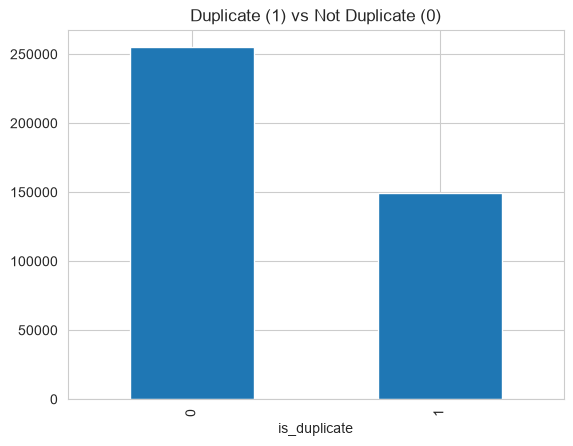

In [4]:
counts = df['is_duplicate'].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(2))

counts.plot(kind='bar', title='Duplicate (1) vs Not Duplicate (0)')
plt.show()

## 3. Question re-use

How many distinct questions appear, and how often do the same questions get re-asked?

Unique questions: 537929
Questions asked more than once: 111778


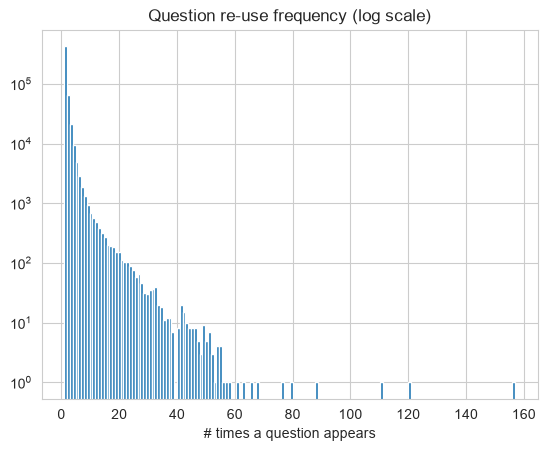

In [5]:
qids = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Unique questions:', qids.nunique())
repeated = qids.value_counts()
print('Questions asked more than once:', (repeated > 1).sum())

plt.hist(repeated.values, bins=160)
plt.yscale('log')
plt.title('Question re-use frequency (log scale)')
plt.xlabel('# times a question appears')
plt.show()

## 4. Question length distribution

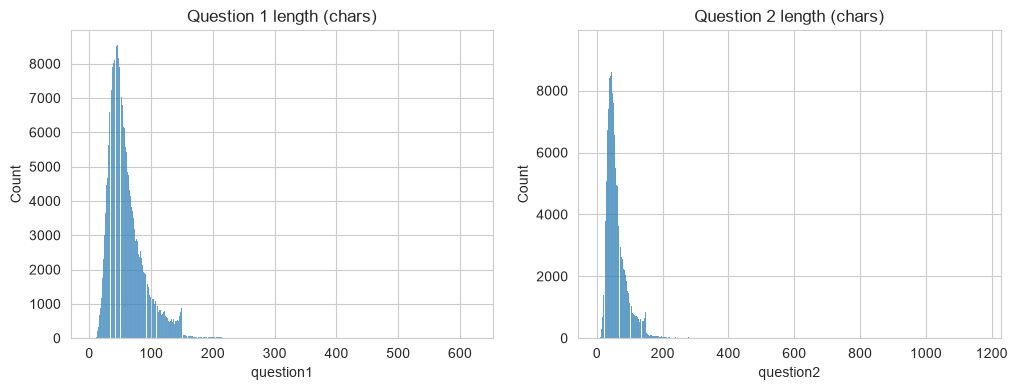

Q1 chars -> min: 1 max: 623 mean: 59.5
Q2 chars -> min: 1 max: 1169 mean: 60.1


In [6]:
q1_len = df['question1'].str.len()
q2_len = df['question2'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(q1_len, ax=axes[0]).set_title('Question 1 length (chars)')
sns.histplot(q2_len, ax=axes[1]).set_title('Question 2 length (chars)')
plt.show()

print('Q1 chars -> min:', q1_len.min(), 'max:', q1_len.max(), 'mean:', round(q1_len.mean(), 1))
print('Q2 chars -> min:', q2_len.min(), 'max:', q2_len.max(), 'mean:', round(q2_len.mean(), 1))

## 5. Do duplicates share more words? (sanity check for feature engineering)

A quick sanity check that motivates the engineered features in `src/features.py`: duplicate pairs should show visibly higher lexical overlap than non-duplicates.

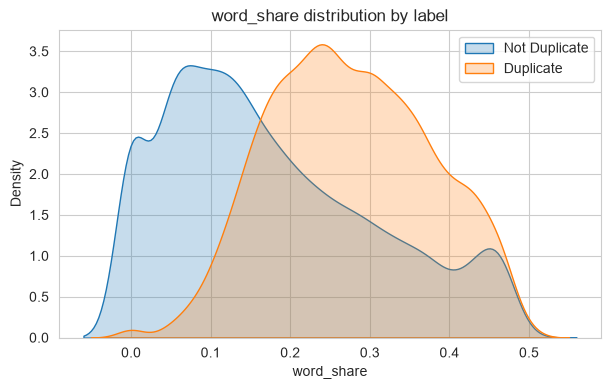

In [7]:
from src.features import add_basic_features

sample = df.sample(20000, random_state=2).reset_index(drop=True)
sample['question1'] = sample['question1'].astype(str)
sample['question2'] = sample['question2'].astype(str)
sample = add_basic_features(sample)

plt.figure(figsize=(7, 4))
sns.kdeplot(sample[sample['is_duplicate'] == 0]['word_share'], label='Not Duplicate', fill=True)
sns.kdeplot(sample[sample['is_duplicate'] == 1]['word_share'], label='Duplicate', fill=True)
plt.legend()
plt.title('word_share distribution by label')
plt.show()

**Takeaway:** duplicate pairs are visibly shifted toward higher `word_share`, "
which is the core signal the engineered features + TF-IDF + model are exploiting. See `notebooks/02_model_experiments.ipynb` for full feature engineering + model comparison, or just run `python -m src.train` for the production pipeline.